# Part B: Boxplot & Outliers

## Step 1 & 2: Load and display dataset

In [20]:
import pandas as pd
df2 = pd.read_csv("demo.csv")
print(df2.head())

   math_score  reading_score  writing_score
0        88.0           85.0            NaN
1        95.0           98.0          100.0
2        30.0           35.0           32.0
3         NaN           70.0           68.0
4       200.0          180.0           90.0


## Step 3: Draw Boxplot

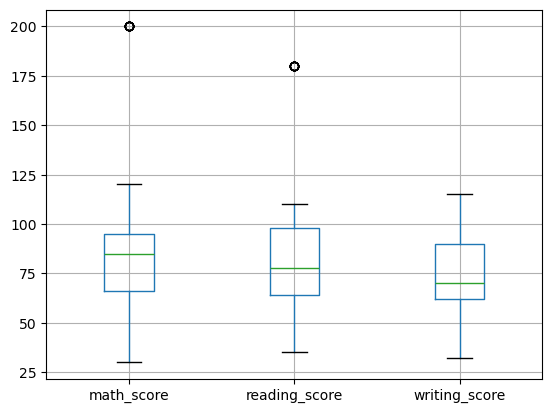

In [21]:
import matplotlib.pyplot as plt

df2.boxplot()
plt.show()

## Step 4: Print Outliers using IQR
Formula:
IQR = Q3 − Q1 
Lower = Q1 − 1.5 × IQR
Upper = Q3 + 1.5 × IQR

In [22]:
for col in df2.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df2[(df2[col] < lower) | (df2[col] > upper)]
    
    print(f"\nOutliers in {col}:\n", outliers[col])


Outliers in math_score:
 4     200.0
12    200.0
18    200.0
23    200.0
37    200.0
40    200.0
50    200.0
76    200.0
78    200.0
99    200.0
Name: math_score, dtype: float64

Outliers in reading_score:
 4     180.0
12    180.0
18    180.0
23    180.0
37    180.0
40    180.0
50    180.0
76    180.0
78    180.0
99    180.0
Name: reading_score, dtype: float64

Outliers in writing_score:
 Series([], Name: writing_score, dtype: float64)


## Step 5: Z-score for math_score

In [23]:
import numpy as np

mean = df2['math_score'].mean()
std = df2['math_score'].std()

df2['z_score'] = (df2['math_score'] - mean) / std

# Outliers (|z| > 3)
outliers = df2[np.abs(df2['z_score']) > 3]

print("Outliers using Z-score:\n", outliers[['math_score', 'z_score']])

Outliers using Z-score:
 Empty DataFrame
Columns: [math_score, z_score]
Index: []
